# Notebook 3: RFM Customer Segmentation

---

## Objective

This notebook implements RFM (Recency, Frequency, Monetary) analysis to segment customers based on their purchasing behavior. This is a classic marketing analytics technique for customer value assessment.

---

## Business Context

Not all customers are equal. Some buy frequently and spend generously. Others purchased once and never returned. The business needs to:

- Identify its most valuable customers (Champions)
- Detect customers at risk of leaving (At Risk)
- Find customers with growth potential (Potential Loyalists)
- Understand why some customers never return

---

## What is RFM Analysis?

RFM analysis answers three critical questions:

| Component | Question | Higher is Better? |
|-----------|----------|-------------------|
| Recency | How recently did the customer purchase? | Lower days = Better |
| Frequency | How often do they purchase? | Higher = Better |
| Monetary | How much do they spend? | Higher = Better |

---

## What This Notebook Covers

- Calculating Recency, Frequency, and Monetary scores for each customer
- Creating RFM score cards (1-4 scale for each dimension)
- Segmenting customers into 8 business-relevant categories
- Analyzing revenue contribution by segment
- Creating RFM heatmaps for visualization
- Generating actionable segment descriptions

---

## Key Business Questions Answered

1. Which customers are our most valuable (Champions)?
2. Which customers need immediate retention efforts (At Risk)?
3. Where should we focus marketing budget?
4. What is the revenue distribution across segments?
5. How many customers are one-time vs repeat buyers?

---

## Expected Output

- RFM scores for each customer saved to `../outputs/tables/rfm_analysis.csv`
- Segment analysis saved to `../outputs/tables/segment_analysis.csv`
- Visualization of segment distribution and revenue contribution
- Actionable segment names and descriptions for business teams

---

## Begin Analysis

Run the cells below to perform RFM customer segmentation.


### Import Libraries and Load Data

In [24]:
# Import libraries for RFM analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data from previous notebook
df = pd.read_csv('../data/processed/online_retail_clean.csv', parse_dates=['InvoiceDate'])

print("Data loaded successfully!")
print(f"Total transactions: {len(df):,}")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")

Data loaded successfully!
Total transactions: 396,337
Date range: 2010-12-01 to 2011-12-09


### What is RFM Analysis?

In [25]:
print("=" * 70)
print("WHAT IS RFM ANALYSIS?")
print("=" * 70)

print("""
RFM analysis is a customer segmentation method used by businesses to:
- Identify their best customers
- Predict which customers might leave
- Target marketing efforts effectively

The three components are:
┌─────────────────────────────────────────────────────────────┐
│  RECENCY: How recently did a customer make a purchase?      │
│           (Lower days = Better - means recently active)      │
│                                                             │
│  FREQUENCY: How often does a customer make a purchase?      │
│             (Higher = Better - means loyal customer)         │
│                                                             │
│  MONETARY: How much money does a customer spend?            │
│            (Higher = Better - means valuable customer)       │
└─────────────────────────────────────────────────────────────┘

Example: A customer who bought yesterday (Recency=1), buys weekly (Frequency=52),
         and spends $500/year (Monetary=500) is a CHAMPION customer.
""")

WHAT IS RFM ANALYSIS?

RFM analysis is a customer segmentation method used by businesses to:
- Identify their best customers
- Predict which customers might leave
- Target marketing efforts effectively

The three components are:
┌─────────────────────────────────────────────────────────────┐
│  RECENCY: How recently did a customer make a purchase?      │
│           (Lower days = Better - means recently active)      │
│                                                             │
│  FREQUENCY: How often does a customer make a purchase?      │
│             (Higher = Better - means loyal customer)         │
│                                                             │
│  MONETARY: How much money does a customer spend?            │
│            (Higher = Better - means valuable customer)       │
└─────────────────────────────────────────────────────────────┘

Example: A customer who bought yesterday (Recency=1), buys weekly (Frequency=52),
         and spends $500/year (Monetary=500) 

### Define Analysis Date and Calculate RFM

In [26]:
# Define the analysis date (day after last transaction in dataset)
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Last transaction date: {df['InvoiceDate'].max().date()}")
print(f"Analysis reference date: {analysis_date.date()}")
print("\nWhy this matters: Recency is calculated as days since last purchase from this date.")

# Calculate RFM metrics for each customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (analysis_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency (unique invoices)
    'TotalPrice': 'sum'  # Monetary (total spending)
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})

print(f"\nRFM data calculated for {len(rfm):,} unique customers")
print("\nFirst 5 customers (sample):")
print(rfm.head())

Last transaction date: 2011-12-09
Analysis reference date: 2011-12-10

Why this matters: Recency is calculated as days since last purchase from this date.

RFM data calculated for 4,334 unique customers

First 5 customers (sample):
            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1437.24
12349.0          19          1   1457.55
12350.0         310          1    294.40


### RFM Statistical Summary

In [27]:
print("RFM STATISTICAL SUMMARY")
print("=" * 50)
print(rfm.describe())

print("\nWhat these numbers tell us:")
print(f"- Average customer last purchased {rfm['Recency'].mean():.1f} days ago")
print(f"- Average customer made {rfm['Frequency'].mean():.2f} purchases")
print(f"- Average customer spent ${rfm['Monetary'].mean():.2f} total")

print(f"\nMedian values (more resistant to outliers):")
print(f"- Typical customer last purchased {rfm['Recency'].median():.0f} days ago")
print(f"- Typical customer made {rfm['Frequency'].median():.0f} purchases")
print(f"- Typical customer spent ${rfm['Monetary'].median():.2f}")

RFM STATISTICAL SUMMARY
           Recency    Frequency       Monetary
count  4334.000000  4334.000000    4334.000000
mean     92.703046     4.245962    2021.473616
std     100.177047     7.634989    8907.501378
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     305.560000
50%      51.000000     2.000000     668.125000
75%     143.000000     5.000000    1631.622500
max     374.000000   206.000000  279138.020000

What these numbers tell us:
- Average customer last purchased 92.7 days ago
- Average customer made 4.25 purchases
- Average customer spent $2021.47 total

Median values (more resistant to outliers):
- Typical customer last purchased 51 days ago
- Typical customer made 2 purchases
- Typical customer spent $668.12


### Create RFM Scores (1-4 Scale) with Business Explanation

In [28]:
print("CREATING RFM SCORES")
print("=" * 50)

print("""
How RFM Scoring Works:
- Each customer gets a score of 1, 2, 3, or 4 for Recency, Frequency, and Monetary
- 4 = Best, 1 = Worst

For Recency: 4 = Recent purchase, 1 = Long time no purchase
For Frequency: 4 = Many purchases, 1 = Few purchases  
For Monetary: 4 = High spending, 1 = Low spending

A customer with score 4-4-4 is your PERFECT customer!
""")

# Create Recency scores (lower recency = better = higher score)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=['4', '3', '2', '1'], duplicates='drop')

# Create Frequency scores (higher frequency = better = higher score)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'], duplicates='drop')

# Create Monetary scores (higher monetary = better = higher score)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 4, labels=['1', '2', '3', '4'], duplicates='drop')

# Combine scores into a single RFM score string (e.g., "4-4-4")
rfm['RFM_Score_String'] = rfm['R_Score'].astype(str) + '-' + rfm['F_Score'].astype(str) + '-' + rfm['M_Score'].astype(str)

# Calculate total score (sum of all three)
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

print("\nRFM Score Distribution:")
print(rfm['RFM_Total'].value_counts().sort_index())

print("\nTop 10 customers (highest RFM scores):")
print(rfm.nlargest(10, 'RFM_Total')[['Recency', 'Frequency', 'Monetary', 'RFM_Score_String']])

CREATING RFM SCORES

How RFM Scoring Works:
- Each customer gets a score of 1, 2, 3, or 4 for Recency, Frequency, and Monetary
- 4 = Best, 1 = Worst

For Recency: 4 = Recent purchase, 1 = Long time no purchase
For Frequency: 4 = Many purchases, 1 = Few purchases  
For Monetary: 4 = High spending, 1 = Low spending

A customer with score 4-4-4 is your PERFECT customer!


RFM Score Distribution:
RFM_Total
3     302
4     505
5     480
6     510
7     431
8     425
9     416
10    394
11    374
12    497
Name: count, dtype: int64

Top 10 customers (highest RFM scores):
            Recency  Frequency  Monetary RFM_Score_String
CustomerID                                               
12347.0           2          7   4310.00            4-4-4
12362.0           3         10   4737.23            4-4-4
12388.0          16          6   2780.66            4-4-4
12417.0           3          9   3226.10            4-4-4
12423.0           1          8   1634.31            4-4-4
12433.0           1   

### Define Customer Segments (Business-Friendly Names)

In [29]:
# Define function to segment customers based on their RFM scores
def classify_customer(row):
    r_score = int(row['R_Score'])
    f_score = int(row['F_Score'])
    m_score = int(row['M_Score'])
    
    # Business logic for customer segmentation
    if r_score >= 3 and f_score >= 4 and m_score >= 4:
        return 'Champions (Best Customers)'
    elif r_score >= 3 and f_score >= 3 and m_score >= 3:
        return 'Loyal Customers'
    elif r_score >= 4 and f_score <= 2:
        return 'New Customers'
    elif r_score == 2 and f_score >= 3 and m_score >= 3:
        return 'Potential Loyalists'
    elif r_score <= 2 and f_score >= 2 and m_score >= 3:
        return 'At Risk (Need Retention)'
    elif r_score == 1 and f_score >= 3 and m_score >= 3:
        return 'Cannot Lose (High Value At Risk)'
    elif r_score <= 2 and f_score <= 2 and m_score <= 2:
        return 'Hibernating (Low Engagement)'
    else:
        return 'Regular Customers'

# Apply segmentation to all customers
rfm['Segment'] = rfm.apply(classify_customer, axis=1)

print("Customer Segmentation Complete!")
print(f"\nTotal customers segmented: {len(rfm):,}")
print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())

Customer Segmentation Complete!

Total customers segmented: 4,334

Segment Distribution:
Segment
Hibernating (Low Engagement)    1244
Regular Customers                935
Champions (Best Customers)       708
Loyal Customers                  610
Potential Loyalists              363
At Risk (Need Retention)         243
New Customers                    231
Name: count, dtype: int64


### Segment Distribution Visualization

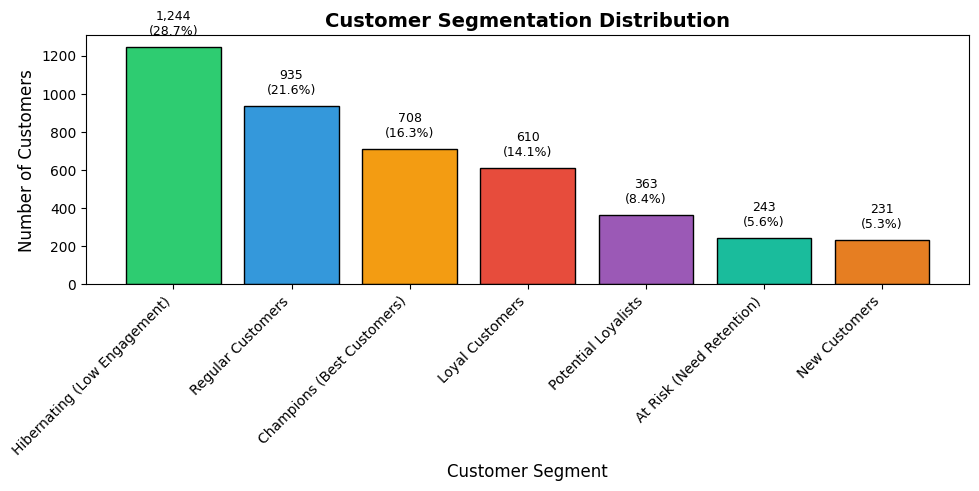

HOW TO READ THIS CHART:
- Each bar represents a customer segment
- Height shows number of customers in that segment
- Top of bar shows count and percentage of total customers


In [30]:
# Calculate segment percentages
segment_counts = rfm['Segment'].value_counts()
segment_percentages = (segment_counts / len(rfm) * 100).round(1)

# Create bar chart
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
bars = plt.bar(range(len(segment_counts)), segment_counts.values, color=colors[:len(segment_counts)], edgecolor='black')
plt.xticks(range(len(segment_counts)), segment_counts.index, rotation=45, ha='right', fontsize=10)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Customer Segmentation Distribution', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, count, pct in zip(bars, segment_counts.values, segment_percentages.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/segment_distribution_bars.png', dpi=100)
plt.show()

print("HOW TO READ THIS CHART:")
print("- Each bar represents a customer segment")
print("- Height shows number of customers in that segment")
print("- Top of bar shows count and percentage of total customers")

### Segment Revenue Contribution

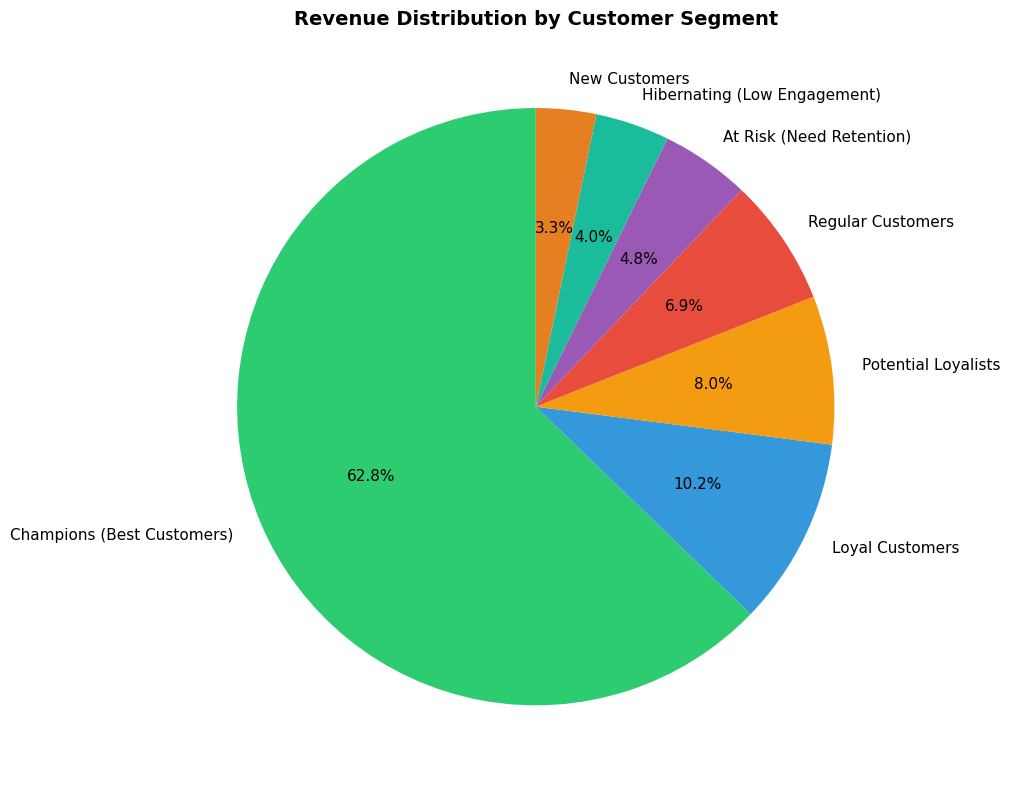

HOW TO READ THIS CHART:
- Each slice represents a customer segment
- Slice size shows what percentage of total revenue comes from that segment
- Example: If 'Champions' is 30%, they generate 30% of all revenue

REVENUE BREAKDOWN:
  Champions (Best Customers): $5,500,224.30 (62.8%)
  Loyal Customers: $892,761.81 (10.2%)
  Potential Loyalists: $703,374.63 (8.0%)
  Regular Customers: $605,068.35 (6.9%)
  At Risk (Need Retention): $423,318.35 (4.8%)
  Hibernating (Low Engagement): $351,318.59 (4.0%)
  New Customers: $285,000.62 (3.3%)


In [31]:
# Calculate revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c', '#e67e22']
plt.pie(segment_revenue.values, labels=segment_revenue.index, autopct='%1.1f%%', 
        colors=colors[:len(segment_revenue)], startangle=90, textprops={'fontsize': 11})
plt.title('Revenue Distribution by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/revenue_by_segment_pie.png', dpi=100)
plt.show()

print("HOW TO READ THIS CHART:")
print("- Each slice represents a customer segment")
print("- Slice size shows what percentage of total revenue comes from that segment")
print("- Example: If 'Champions' is 30%, they generate 30% of all revenue")

print("\nREVENUE BREAKDOWN:")
for segment, revenue in segment_revenue.items():
    percentage = (revenue / segment_revenue.sum() * 100)
    print(f"  {segment}: ${revenue:,.2f} ({percentage:.1f}%)")

## RFM Heatmap (Recency vs Frequency)

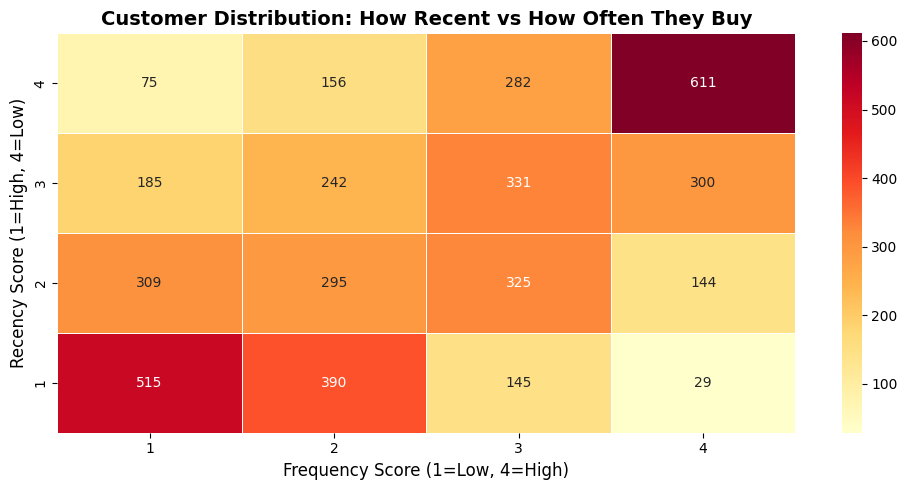

HOW TO READ THIS HEATMAP:
- Darker red = More customers in that combination
- Top-right corner (R_Score=4, F_Score=4): Recent AND frequent buyers (BEST)
- Bottom-left corner (R_Score=1, F_Score=1): Not recent AND infrequent buyers (WORST)
- Use this to identify where most of your customers fall


In [32]:
# Create a heatmap showing customer concentration
rfm_heatmap = rfm.groupby(['R_Score', 'F_Score']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(rfm_heatmap, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.xlabel('Frequency Score (1=Low, 4=High)', fontsize=12)
plt.ylabel('Recency Score (1=High, 4=Low)', fontsize=12)
plt.title('Customer Distribution: How Recent vs How Often They Buy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/rfm_heatmap.png', dpi=100)
plt.show()

print("HOW TO READ THIS HEATMAP:")
print("- Darker red = More customers in that combination")
print("- Top-right corner (R_Score=4, F_Score=4): Recent AND frequent buyers (BEST)")
print("- Bottom-left corner (R_Score=1, F_Score=1): Not recent AND infrequent buyers (WORST)")
print("- Use this to identify where most of your customers fall")

## Segment Analysis with Business Metrics

In [33]:
# Calculate key metrics for each segment
# Use 'size()' instead of counting CustomerID since it's the index
segment_analysis = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})

# Add customer count using size() instead of counting a column
segment_analysis['Customer_Count'] = rfm.groupby('Segment').size()

# Add derived metrics
segment_analysis['Revenue_Share'] = (segment_analysis['Monetary'] / segment_analysis['Monetary'].sum() * 100).round(1)
segment_analysis['Avg_Order_Value'] = segment_analysis['Monetary'] / segment_analysis['Frequency']
segment_analysis['Pct_of_Customers'] = (segment_analysis['Customer_Count'] / len(rfm) * 100).round(1)

# Sort by revenue share
segment_analysis = segment_analysis.sort_values('Revenue_Share', ascending=False)

print("FULL SEGMENT ANALYSIS - BUSINESS METRICS")
print("=" * 80)
print(segment_analysis.round(2).to_string())

# Save to CSV
segment_analysis.to_csv('../outputs/tables/segment_analysis.csv')
print("\nSegment analysis saved to ../outputs/tables/segment_analysis.csv")

FULL SEGMENT ANALYSIS - BUSINESS METRICS
                              Recency  Frequency  Monetary  Customer_Count  Revenue_Share  Avg_Order_Value  Pct_of_Customers
Segment                                                                                                                     
Champions (Best Customers)      14.48      13.56   7768.68             708           51.5           572.82              16.3
Potential Loyalists             82.46       4.66   1937.67             363           12.9           416.20               8.4
At Risk (Need Retention)       165.44       2.87   1742.05             243           11.6           606.47               5.6
Loyal Customers                 20.05       4.40   1463.54             610            9.7           333.00              14.1
New Customers                   10.03       1.55   1233.77             231            8.2           798.32               5.3
Regular Customers               68.92       2.03    647.13             935          

### Business Recommendations by Segment

In [34]:
print("=" * 80)
print("BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT")
print("=" * 80)

recommendations = {
    'Champions (Best Customers)': {
        'Action': 'VIP treatment, loyalty rewards, exclusive previews',
        'Goal': 'Keep them happy and increase their spending',
        'Priority': 'Highest'
    },
    'Loyal Customers': {
        'Action': 'Referral programs, upsell complementary products',
        'Goal': 'Convert them to Champions',
        'Priority': 'High'
    },
    'Potential Loyalists': {
        'Action': 'Engagement campaigns, personalized offers',
        'Goal': 'Build loyalty before they lose interest',
        'Priority': 'High'
    },
    'New Customers': {
        'Action': 'Welcome series, first-purchase follow-up',
        'Goal': 'Get them to buy again',
        'Priority': 'Medium'
    },
    'At Risk (Need Retention)': {
        'Action': 'Re-engagement emails, special discounts',
        'Goal': 'Win them back before they leave forever',
        'Priority': 'Urgent'
    },
    'Cannot Lose (High Value At Risk)': {
        'Action': 'Personal outreach, exclusive offers',
        'Goal': 'Immediate retention of valuable customers',
        'Priority': 'Critical'
    },
    'Hibernating (Low Engagement)': {
        'Action': 'Periodic re-activation campaigns',
        'Goal': 'Low-cost attempts to re-engage',
        'Priority': 'Low'
    },
    'Regular Customers': {
        'Action': 'Standard marketing, build relationship',
        'Goal': 'Move to higher value segments',
        'Priority': 'Normal'
    }
}

for segment, rec in recommendations.items():
    if segment in segment_analysis.index:
        print(f"\n {segment}")
        print(f"   Customer Count: {segment_analysis.loc[segment, 'Customer_Count']:,}")
        print(f"   Revenue Share: {segment_analysis.loc[segment, 'Revenue_Share']:.1f}%")
        print(f"   Action: {rec['Action']}")
        print(f"   Goal: {rec['Goal']}")
        print(f"   Priority: {rec['Priority']}")

BUSINESS RECOMMENDATIONS BY CUSTOMER SEGMENT

 Champions (Best Customers)
   Customer Count: 708
   Revenue Share: 51.5%
   Action: VIP treatment, loyalty rewards, exclusive previews
   Goal: Keep them happy and increase their spending
   Priority: Highest

 Loyal Customers
   Customer Count: 610
   Revenue Share: 9.7%
   Action: Referral programs, upsell complementary products
   Goal: Convert them to Champions
   Priority: High

 Potential Loyalists
   Customer Count: 363
   Revenue Share: 12.9%
   Action: Engagement campaigns, personalized offers
   Goal: Build loyalty before they lose interest
   Priority: High

 New Customers
   Customer Count: 231
   Revenue Share: 8.2%
   Action: Welcome series, first-purchase follow-up
   Goal: Get them to buy again
   Priority: Medium

 At Risk (Need Retention)
   Customer Count: 243
   Revenue Share: 11.6%
   Action: Re-engagement emails, special discounts
   Goal: Win them back before they leave forever
   Priority: Urgent

 Hibernating (Low

### Segment Prioritization Matrix

In [35]:
# Create a prioritization matrix
priority_data = []
for segment in segment_analysis.index:
    priority_data.append({
        'Segment': segment,
        'Customers': segment_analysis.loc[segment, 'Customer_Count'],
        'Revenue_Share': segment_analysis.loc[segment, 'Revenue_Share'],
        'Avg_Recency': segment_analysis.loc[segment, 'Recency'],
        'Priority': recommendations.get(segment, {}).get('Priority', 'Normal')
    })

priority_df = pd.DataFrame(priority_data)
priority_df = priority_df.sort_values('Revenue_Share', ascending=False)

# Color coding for priority
def priority_color(priority):
    colors = {
        'Critical': ' CRITICAL',
        'Urgent': ' URGENT',
        'Highest': ' HIGHEST',
        'High': ' HIGH',
        'Medium': ' MEDIUM',
        'Normal': ' NORMAL',
        'Low': ' LOW'
    }
    return colors.get(priority, ' NORMAL')

print("SEGMENT PRIORITIZATION MATRIX")
print("=" * 80)
print("\nPriority Legend:")
print("  CRITICAL - Immediate action required")
print("   URGENT - Action within 2 weeks")
print("   HIGHEST - Top priority for resources")
print("   HIGH - Important but not critical")
print("   MEDIUM - Schedule for next quarter")
print("   NORMAL - Business as usual")
print("   LOW - Low priority")

print("\n" + "-" * 80)
for _, row in priority_df.iterrows():
    priority_display = priority_color(row['Priority'])
    print(f"{priority_display:12} | {row['Segment'][:35]:35} | {row['Customers']:>6} customers | {row['Revenue_Share']:>5}% revenue")

SEGMENT PRIORITIZATION MATRIX

Priority Legend:
  CRITICAL - Immediate action required
   URGENT - Action within 2 weeks
   HIGHEST - Top priority for resources
   HIGH - Important but not critical
   MEDIUM - Schedule for next quarter
   NORMAL - Business as usual
   LOW - Low priority

--------------------------------------------------------------------------------
 HIGHEST     | Champions (Best Customers)          |    708 customers |  51.5% revenue
 HIGH        | Potential Loyalists                 |    363 customers |  12.9% revenue
 URGENT      | At Risk (Need Retention)            |    243 customers |  11.6% revenue
 HIGH        | Loyal Customers                     |    610 customers |   9.7% revenue
 MEDIUM      | New Customers                       |    231 customers |   8.2% revenue
 NORMAL      | Regular Customers                   |    935 customers |   4.3% revenue
 LOW         | Hibernating (Low Engagement)        |   1244 customers |   1.9% revenue


### Visualize Segment Priority

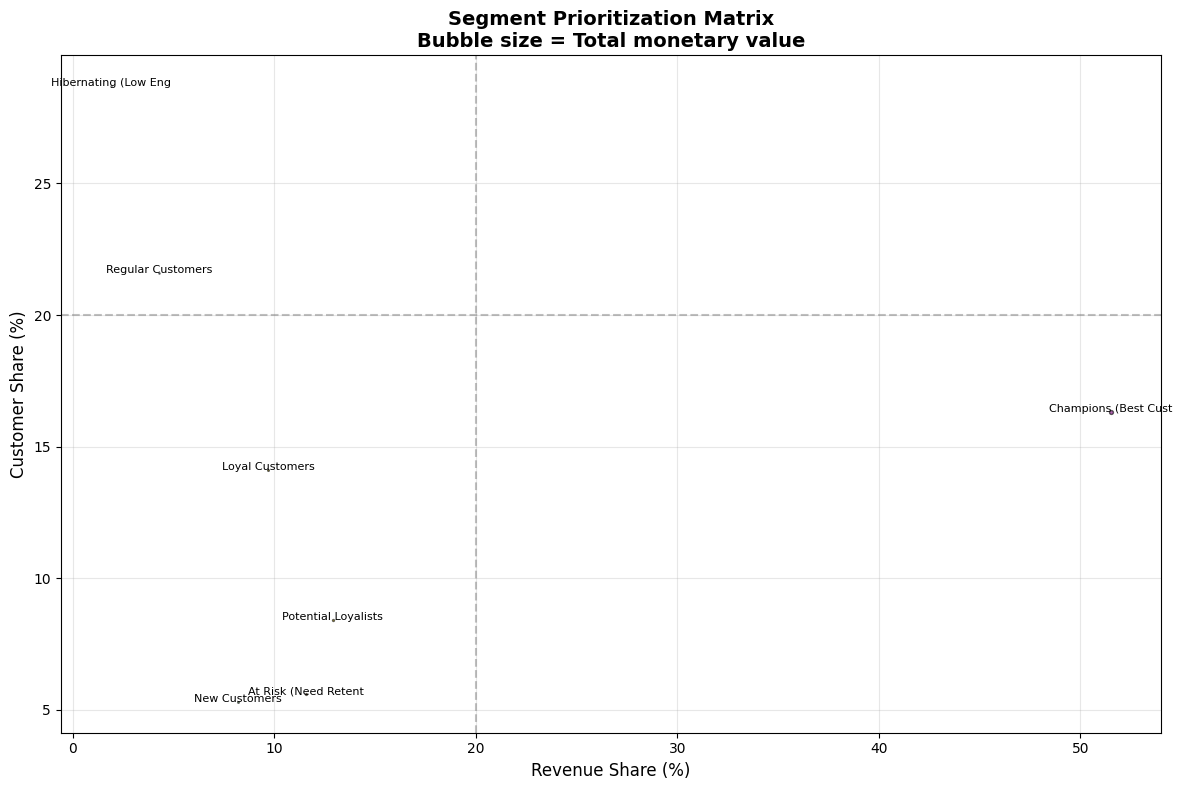

HOW TO READ THIS CHART:
- Top-Right quadrant: High revenue AND high customer count (Focus here)
- Bubble size: Larger bubbles = More total spending from this segment
- Color indicates priority level (see legend above)

Focus your marketing budget on segments in Top-Right or with dark red/orange colors.


In [36]:
# Create a bubble chart for segment prioritization
plt.figure(figsize=(12, 8))

# Map priority to numeric values for visualization
priority_order = {'Critical': 5, 'Urgent': 4, 'Highest': 4, 'High': 3, 'Medium': 2, 'Normal': 1, 'Low': 0}
priority_colors = {'Critical': 'darkred', 'Urgent': 'orange', 'Highest': 'purple', 
                   'High': 'gold', 'Medium': 'lightgreen', 'Normal': 'steelblue', 'Low': 'lightgray'}

for segment in segment_analysis.index:
    priority = recommendations.get(segment, {}).get('Priority', 'Normal')
    priority_num = priority_order.get(priority, 1)
    revenue_share = segment_analysis.loc[segment, 'Revenue_Share']
    customer_pct = segment_analysis.loc[segment, 'Pct_of_Customers']
    color = priority_colors.get(priority, 'steelblue')
    
    plt.scatter(revenue_share, customer_pct, s=segment_analysis.loc[segment, 'Monetary']/1000, 
                c=color, alpha=0.6, edgecolors='black', linewidth=1)
    plt.annotate(segment[:20], (revenue_share, customer_pct), fontsize=8, ha='center')

plt.xlabel('Revenue Share (%)', fontsize=12)
plt.ylabel('Customer Share (%)', fontsize=12)
plt.title('Segment Prioritization Matrix\nBubble size = Total monetary value', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add quadrant lines
plt.axhline(y=20, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=20, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/figures/segment_prioritization_matrix.png', dpi=100)
plt.show()

print("HOW TO READ THIS CHART:")
print("- Top-Right quadrant: High revenue AND high customer count (Focus here)")
print("- Bubble size: Larger bubbles = More total spending from this segment")
print("- Color indicates priority level (see legend above)")
print("\nFocus your marketing budget on segments in Top-Right or with dark red/orange colors.")

### Save RFM Results for Next Notebooks

In [37]:
# Save RFM data for clustering and further analysis
rfm.to_csv('../outputs/tables/rfm_analysis.csv')
print("RFM analysis saved to ../outputs/tables/rfm_analysis.csv")

# Save segment data separately
rfm[['Recency', 'Frequency', 'Monetary', 'Segment', 'RFM_Score_String', 'RFM_Total']].to_csv('../outputs/tables/customer_segments.csv')
print("Customer segments saved to ../outputs/tables/customer_segments.csv")

# Save a simple segment summary for business reporting
segment_summary = rfm.groupby('Segment').size().reset_index(name='Customer_Count')
segment_summary['Percentage'] = (segment_summary['Customer_Count'] / len(rfm) * 100).round(1)
segment_summary.to_csv('../outputs/tables/segment_summary_simple.csv', index=False)
print("Simple segment summary saved to ../outputs/tables/segment_summary_simple.csv")

RFM analysis saved to ../outputs/tables/rfm_analysis.csv
Customer segments saved to ../outputs/tables/customer_segments.csv
Simple segment summary saved to ../outputs/tables/segment_summary_simple.csv


### Final Summary and Next Steps

In [38]:
print("=" * 70)
print("RFM ANALYSIS COMPLETE - KEY FINDINGS")
print("=" * 70)

# Identify top and bottom segments
top_segment = segment_analysis.iloc[0]
bottom_segment = segment_analysis.iloc[-1]
largest_segment = segment_analysis.loc[segment_analysis['Customer_Count'].idxmax()]

print(f"\n Most Valuable Segment: {segment_analysis.index[0]}")
print(f"   - {top_segment['Customer_Count']:,} customers ({top_segment['Pct_of_Customers']:.1f}% of total)")
print(f"   - Generates {top_segment['Revenue_Share']:.1f}% of revenue")
print(f"   - Average spend per customer: ${top_segment['Monetary']:.2f}")

print(f"\n Largest Segment by Customer Count: {largest_segment.name}")
print(f"   - {largest_segment['Customer_Count']:,} customers ({largest_segment['Pct_of_Customers']:.1f}% of total)")
print(f"   - Generates {largest_segment['Revenue_Share']:.1f}% of revenue")

print(f"\nSegment Needing Immediate Attention: At Risk (Need Retention)")
if 'At Risk (Need Retention)' in segment_analysis.index:
    at_risk = segment_analysis.loc['At Risk (Need Retention)']
    print(f"   - {at_risk['Customer_Count']:,} customers at risk of churning")
    print(f"   - These customers represent ${at_risk['Monetary']:,.2f} in at-risk revenue")

print("\n" + "=" * 70)
print("ACTIONABLE INSIGHTS FOR THE BUSINESS")
print("=" * 70)

print("""
1. IMMEDIATE ACTIONS (Next 30 days):
   - Contact 'Cannot Lose (High Value At Risk)' customers personally
   - Launch re-engagement campaign for 'At Risk' segment with 15% discount
   - Implement welcome email series for 'New Customers'

2. SHORT TERM (Next 90 days):
   - Develop VIP program for 'Champions' segment
   - Create referral program for 'Loyal Customers'
   - Test targeted offers on 'Potential Loyalists'

3. LONG TERM (Next 6 months):
   - Build automated RFM scoring system
   - Create segment-specific email marketing automation
   - Develop customer journey maps for each segment

4. SUCCESS METRICS TO TRACK:
   - Reduce customers in 'At Risk' segment by 20%
   - Increase 'Champions' segment by 15%
   - Improve repeat purchase rate among 'New Customers' by 25%
""")

print("\n" + "=" * 70)
print("RFM ANALYSIS COMPLETE")
print("=" * 70)
print("\nWhat we accomplished in this notebook:")
print("1. Segmented all customers into 8 business-relevant groups")
print("2. Quantified the value of each customer segment")
print("3. Identified which segments need immediate attention")
print("4. Provided specific, actionable recommendations")
print("5. Created visualizations that non-technical teams can understand")

print("\nProceed to next notebook: 04_customer_clustering.ipynb")
print("(We will use machine learning to find natural customer groupings)")

RFM ANALYSIS COMPLETE - KEY FINDINGS

 Most Valuable Segment: Champions (Best Customers)
   - 708.0 customers (16.3% of total)
   - Generates 51.5% of revenue
   - Average spend per customer: $7768.68

 Largest Segment by Customer Count: Hibernating (Low Engagement)
   - 1,244.0 customers (28.7% of total)
   - Generates 1.9% of revenue

Segment Needing Immediate Attention: At Risk (Need Retention)
   - 243.0 customers at risk of churning
   - These customers represent $1,742.05 in at-risk revenue

ACTIONABLE INSIGHTS FOR THE BUSINESS

1. IMMEDIATE ACTIONS (Next 30 days):
   - Contact 'Cannot Lose (High Value At Risk)' customers personally
   - Launch re-engagement campaign for 'At Risk' segment with 15% discount
   - Implement welcome email series for 'New Customers'

2. SHORT TERM (Next 90 days):
   - Develop VIP program for 'Champions' segment
   - Create referral program for 'Loyal Customers'
   - Test targeted offers on 'Potential Loyalists'

3. LONG TERM (Next 6 months):
   - Buil